# Libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the data + printing

In [27]:
from sklearn.datasets import fetch_california_housing

cali_housing = fetch_california_housing(as_frame=True)
# Data=pd.get_dummies(Data, dtype=float)


print(cali_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

# Binarizing the target column

In [28]:
data=cali_housing.data
target=cali_housing.target

print(target)

mean_value = np.mean(target)


comparison_result = target > mean_value

binary_array = comparison_result.astype(int)

target=binary_array

print(target)




0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64
0        1
1        1
2        1
3        1
4        1
        ..
20635    0
20636    0
20637    0
20638    0
20639    0
Name: MedHouseVal, Length: 20640, dtype: int64


# Training the model

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn . model_selection import train_test_split
from sklearn. tree import plot_tree


X_train, X_test, y_train, y_test = train_test_split (data, target, test_size = 0.4 )

gini_model = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_model.fit(X_train,y_train)

        

DecisionTreeClassifier(random_state=42)

In [30]:
## printing the model
tree_ = gini_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")



Number of nodes: 2607
Node 0: Split on feature 0 <= 4.10
Node 1: Split on feature 5 <= 2.34
Node 2: Split on feature 6 <= 37.95
Node 3: Split on feature 7 <= -117.22
Node 4: Split on feature 0 <= 2.57
Node 5: Split on feature 7 <= -122.37
Node 6: Split on feature 3 <= 1.03
Node 7: Split on feature 0 <= 2.29
Node 8: Leaf node with impurity 0.00
Node 9: Leaf node with impurity 0.00
Node 10: Leaf node with impurity 0.00
Node 11: Split on feature 5 <= 1.95
Node 12: Split on feature 0 <= 2.02
Node 13: Split on feature 2 <= 3.41
Node 14: Split on feature 5 <= 1.76
Node 15: Split on feature 5 <= 1.53
Node 16: Split on feature 4 <= 2850.50
Node 17: Split on feature 4 <= 390.00
Node 18: Split on feature 1 <= 31.00
Node 19: Leaf node with impurity 0.00
Node 20: Leaf node with impurity 0.00
Node 21: Leaf node with impurity 0.00
Node 22: Leaf node with impurity 0.00
Node 23: Split on feature 0 <= 1.63
Node 24: Split on feature 1 <= 8.00
Node 25: Leaf node with impurity 0.00
Node 26: Leaf node with

# Tuning

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Evaluate the initial model
y_pred_initial = gini_model.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred_initial)
print(f"initial model test accuracy: {initial_accuracy:.4f}")

#  hyperparameter tuning using Grid Search and Cross-Validation 
dt_classifier = DecisionTreeClassifier(criterion='gini', random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10]
}

grid_search = GridSearchCV(
    estimator=dt_classifier, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5,                 
    verbose=1,            
    n_jobs=-1            
)

grid_search.fit(X_train, y_train)

optimal_depth = grid_search.best_params_['max_depth']
print(f"optimal max_depth found: {optimal_depth}")

best_cv_score = grid_search.best_score_
print(f"best croos validation accuracy: {best_cv_score:.4f}")

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_best)

print(f"final model test accuracy: {final_accuracy:.4f}")

initial model test accuracy: 0.8245
Fitting 5 folds for each of 4 candidates, totalling 20 fits


optimal max_depth found: 10
best croos validation accuracy: 0.8416
final model test accuracy: 0.8384


# Evaluation

In [32]:
from sklearn.metrics import classification_report

best_model = DecisionTreeClassifier(criterion='gini', max_depth=optimal_depth, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Classification Report ")
report = classification_report(y_test, y_pred, target_names=['Low-Income (0)', 'High-Income (1)'])
print(report)

Classification Report 
                 precision    recall  f1-score   support

 Low-Income (0)       0.87      0.86      0.87      4960
High-Income (1)       0.79      0.80      0.80      3296

       accuracy                           0.84      8256
      macro avg       0.83      0.83      0.83      8256
   weighted avg       0.84      0.84      0.84      8256



      Feature  Importance
0      MedInc    0.486938
5    AveOccup    0.134581
7   Longitude    0.123340
6    Latitude    0.111038
1    HouseAge    0.055057
2    AveRooms    0.037289
4  Population    0.027906
3   AveBedrms    0.023851


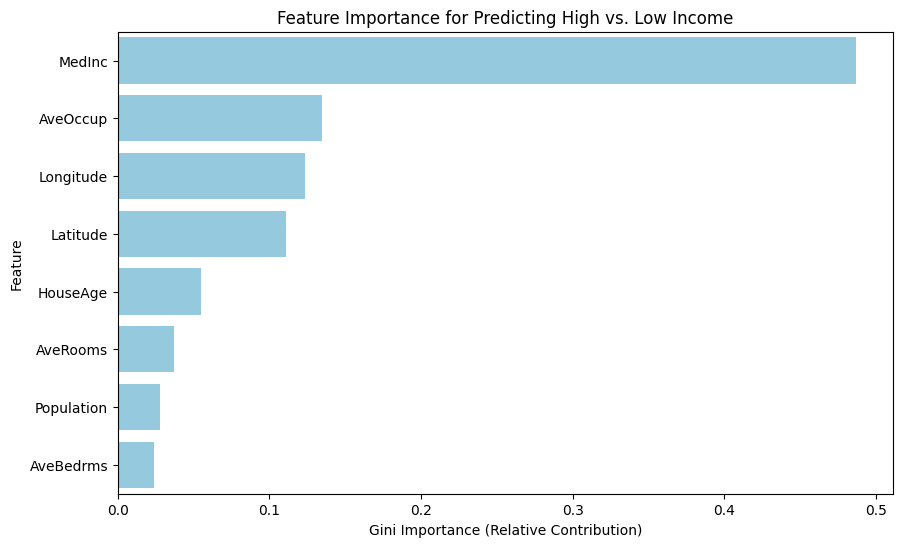

Exception ignored in: <function ResourceTracker.__del__ at 0x7fcb59d022a0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f6de81362a0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ff21cfda2a0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multip

In [33]:
import seaborn as sns
importances = best_model.feature_importances_
feature_names = data.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color='skyblue')
plt.title('Feature Importance for Predicting High vs. Low Income')
plt.xlabel('Gini Importance (Relative Contribution)')
plt.ylabel('Feature')

plt.show()